✅ Model found: /kaggle/input/models/nina000/seg/keras/default/1/final_model.keras
✅ Test files: 4000  (clean=2000, stego=2000)
✅ Model loaded


I0000 00:00:1776890225.865609     115 service.cc:152] XLA service 0x7ac1f4010560 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776890225.865688     115 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1776890226.990657     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  8/4000
  408/4000
  808/4000
  1208/4000
  1608/4000
  2008/4000
  2408/4000
  2808/4000
  3208/4000
  3608/4000

  Accuracy : 83.08%
  AUC-ROC  : 0.9579
              precision    recall  f1-score   support

       Clean       1.00      0.66      0.80      2000
       Stego       0.75      1.00      0.86      2000

    accuracy                           0.83      4000
   macro avg       0.87      0.83      0.83      4000
weighted avg       0.87      0.83      0.83      4000



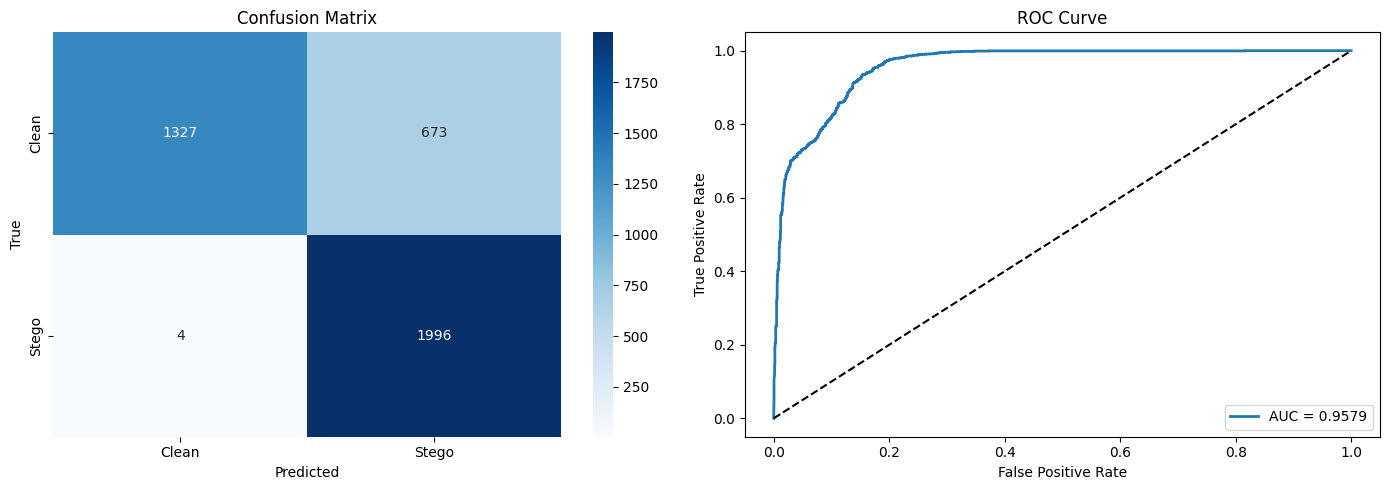

In [5]:
import os, gc
import numpy as np
from PIL import Image
from scipy.ndimage import convolve
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# ── REGISTER CUSTOM ACTIVATION (required to load model) ──────
@tf.keras.utils.register_keras_serializable()
def tlu(x):
    """Truncated Linear Unit — clips activations to [-3, 3]"""
    return tf.clip_by_value(x, -3.0, 3.0)

# ── CONFIG ───────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 8
BASE       = '/kaggle/input/datasets/petrdufek/stego-pvd-dataset/Stego-pvd-dataset'
TEST_CLEAN = os.path.join(BASE, 'test/cleanTest')
TEST_STEGO = os.path.join(BASE, 'test/stegoTest')
SUPPORTED  = {'.png', '.jpg', '.jpeg', '.bmp'}

# Auto-find the .keras model
MODEL_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.keras') or f.endswith('.h5'):
            MODEL_PATH = os.path.join(root, f)
            print(f"✅ Model found: {MODEL_PATH}")
            break
    if MODEL_PATH: break

if MODEL_PATH is None:
    raise FileNotFoundError("❌ No .keras or .h5 model found in /kaggle/input/")

# ── SRM FILTER BANK ──────────────────────────────────────────
SRM_KERNELS = [
    np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]], np.float32) / 8.0,
    np.array([[ 0, 0, 0],[-1, 2,-1],[ 0, 0, 0]], np.float32) / 2.0,
    np.array([[ 0,-1, 0],[ 0, 2, 0],[ 0,-1, 0]], np.float32) / 2.0,
    np.array([[-1, 0, 0],[ 0, 2, 0],[ 0, 0,-1]], np.float32) / 2.0,
    np.array([[ 0, 0,-1],[ 0, 2, 0],[-1, 0, 0]], np.float32) / 2.0,
    np.array([[ 0,-1, 0],[-1, 4,-1],[ 0,-1, 0]], np.float32) / 4.0,
]

def apply_srm(arr):
    out = np.mean([
        np.stack([convolve(arr[:,:,c], k) for c in range(3)], axis=-1)
        for k in SRM_KERNELS
    ], axis=0)
    out -= out.min()
    mx = out.max()
    if mx > 0: out /= mx
    return out.astype(np.float32)

def load_image(path):
    img = Image.open(path).convert("RGB")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    return apply_srm(arr)

# ── FILE LIST ─────────────────────────────────────────────────
def get_file_list(clean_dir, stego_dir):
    pairs = []
    for f in os.listdir(clean_dir):
        if os.path.splitext(f)[1].lower() in SUPPORTED:
            pairs.append((os.path.join(clean_dir, f), 0))
    for f in os.listdir(stego_dir):
        if os.path.splitext(f)[1].lower() in SUPPORTED:
            pairs.append((os.path.join(stego_dir, f), 1))
    return pairs

test_files = get_file_list(TEST_CLEAN, TEST_STEGO)
print(f"✅ Test files: {len(test_files)}  (clean={sum(1 for _,l in test_files if l==0)}, stego={sum(1 for _,l in test_files if l==1)})")

# ── LOAD MODEL (with custom_objects) ─────────────────────────
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"tlu": tlu})
print("✅ Model loaded")

# ── INFERENCE ─────────────────────────────────────────────────
y_true, y_prob = [], []
for i in range(0, len(test_files), BATCH_SIZE):
    batch = test_files[i : i + BATCH_SIZE]
    imgs  = np.stack([load_image(p) for p, _ in batch], axis=0)
    preds = model.predict(imgs, verbose=0).flatten()
    y_true.extend([l for _, l in batch])
    y_prob.extend(preds.tolist())
    if (i // BATCH_SIZE) % 50 == 0:
        print(f"  {min(i+BATCH_SIZE, len(test_files))}/{len(test_files)}")
    del imgs; gc.collect()

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

# ── METRICS ───────────────────────────────────────────────────
acc = (y_pred == y_true).mean() * 100
auc = roc_auc_score(y_true, y_prob)
print(f"\n{'='*50}\n  Accuracy : {acc:.2f}%\n  AUC-ROC  : {auc:.4f}\n{'='*50}")
print(classification_report(y_true, y_pred, target_names=["Clean", "Stego"]))

# ── PLOTS ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=["Clean","Stego"], yticklabels=["Clean","Stego"])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('/kaggle/working/test_results.png', dpi=150)
plt.show()